# Imports & Setup

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score, mean_absolute_error

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
# 2. Load Dataset
df = pd.read_csv("../data/dataset.csv")
df.head()

,user_id,name,age,gender,city,sector,marital_status,dependents,email,phone,...,total_debt,total_monthly_emi,debt_to_income_ratio_x,savings_ratio,expense_ratio,emi_ratio,emergency_fund_months,debt_to_income_ratio_y,stress_score,stress_level
0,USER_000001,Aryan Maharaj,62,Male,Mumbai,Education,Married,1,udantdewan@example.net,918196001338,...,3650885,40737,0.2448,0.0235,0.9538,0.2448,7.27,0.2448,60,High
1,USER_000002,Rushil Saini,28,Other,Jaipur,Banking,Married,0,saumyamall@example.org,916542351161,...,113061,2826,0.0233,0.1278,0.7691,0.0233,6.39,0.0233,30,Medium
2,USER_000003,Aishani Bassi,27,Male,Hyderabad,IT,Married,2,hyadav@example.com,918495931034,...,0,0,0.0000,0.0000,1.1118,0.0000,1.92,0.0000,70,High
3,USER_000004,Harrison Rai,56,Female,Hyderabad,Government,Married,3,sudiksha52@example.com,3419283276,...,0,0,0.0000,0.0000,1.4057,0.0000,2.71,0.0000,70,High
4,USER_000005,Ekta Bhalla,22,Male,Kolkata,Retail,Single,0,azadmutti@example.com,1395376724,...,516706,9907,0.1465,0.0010,0.9978,0.1465,13.70,0.1465,55,Medium


In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 10000 non-null  object 
 1   name                    10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   gender                  10000 non-null  object 
 4   city                    10000 non-null  object 
 5   sector                  10000 non-null  object 
 6   marital_status          10000 non-null  object 
 7   dependents              10000 non-null  int64  
 8   email                   10000 non-null  object 
 9   phone                   10000 non-null  int64  
 10  created_at              10000 non-null  object 
 11  annual_salary           10000 non-null  int64  
 12  bonus                   10000 non-null  int64  
 13  rental_income           10000 non-null  int64  
 14  interest_income         10000 non-null 

# Preprocessing

In [164]:
# Feature Selection

numeric_cols = [
    'total_income', 
    'total_monthly_expenses', 
    'savings_account', 
    'fixed_deposits', 
    'mutual_funds', 
    'stocks', 
    'ppf', 
    'gold', 
    'emergency_fund'
]
# Derived features
df['savings_ratio'] = df['savings_account'] / df['total_income']
df['expense_ratio'] = df['total_monthly_expenses'] * 12 / df['total_income']
df['div_count'] = df[['fixed_deposits','mutual_funds','ppf','stocks','gold','emergency_fund']].gt(0).sum(axis=1)

features = numeric_cols + ['savings_ratio', 'expense_ratio', 'div_count']


# Target 

target = 'stress_score'

X = df[features]
y = df[target]

In [165]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [166]:
percentiles = X_test[numeric_cols].quantile([0.05, 0.95])
print(percentiles)

      total_income  total_monthly_expenses  savings_account  fixed_deposits  \
0.05     752935.85                 61482.1         72468.25             0.0   
0.95    3995706.10                336126.0        478273.75        915085.0   

      mutual_funds     stocks        ppf       gold  emergency_fund  
0.05          0.00        0.0       0.00       0.00       101282.75  
0.95     729418.25  1339530.1  445471.05  240086.55      1217768.45  


In [167]:
# Winsorization
for col in numeric_cols:
    lower = percentiles.loc[0.05, col]
    upper = percentiles.loc[0.95, col]
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

# ML Models

#### We will now use various Machine Learning models to predict Stress Score using this training data

In [185]:
results=[]

In [186]:
# CatBoost
cat_model = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, verbose=100)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2_cat = r2_score(y_test, y_pred_cat)
mae_cat  = mean_absolute_error(y_test, y_pred_cat)
results.append(['CatBoost', rmse_cat, r2_cat, mae_cat])

0:	learn: 10.8593794	total: 62.6ms	remaining: 1m 2s
100:	learn: 6.0265211	total: 718ms	remaining: 6.39s
200:	learn: 5.4797386	total: 1.28s	remaining: 5.09s
300:	learn: 5.0815916	total: 1.85s	remaining: 4.29s
400:	learn: 4.7663207	total: 2.37s	remaining: 3.55s
500:	learn: 4.5053959	total: 2.91s	remaining: 2.9s
600:	learn: 4.2765617	total: 3.63s	remaining: 2.41s
700:	learn: 4.0656256	total: 4.53s	remaining: 1.93s
800:	learn: 3.8741530	total: 5.29s	remaining: 1.31s
900:	learn: 3.6999768	total: 6.07s	remaining: 667ms
999:	learn: 3.5501824	total: 6.6s	remaining: 0us


In [187]:
# XGBoost
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
results.append(['XGBoost', rmse_xgb, r2_xgb, mae_xgb])

In [188]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=1000, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
results.append(['Random Forest', rmse_rf, r2_rf, mae_rf])

In [189]:
# Linear Regression
# For Linear Regression, we should normalize the input data through scaling
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)
mae_lin  = mean_absolute_error(y_test, y_pred_lin)
results.append(['Linear Regression', rmse_lin, r2_lin, mae_lin])

In [190]:
# Ridge Regression
# Again using scaled input data
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
results.append(['Ridge Regression', rmse_ridge, r2_ridge, mae_ridge])

# ML Results

In [191]:
results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'R²', 'MAE'])
results_df = results_df.sort_values(by='RMSE')
results_df.reset_index(drop=True, inplace=True)

results_df

,Model,RMSE,R²,MAE
0,Random Forest,6.511731,0.685638,4.141040
1,CatBoost,6.830341,0.654123,4.336022
2,XGBoost,7.080921,0.628280,4.455266
3,Linear Regression,8.729191,0.435082,6.273297
4,Ridge Regression,8.729758,0.435009,6.273429


### Comparing results by RMSE and R²

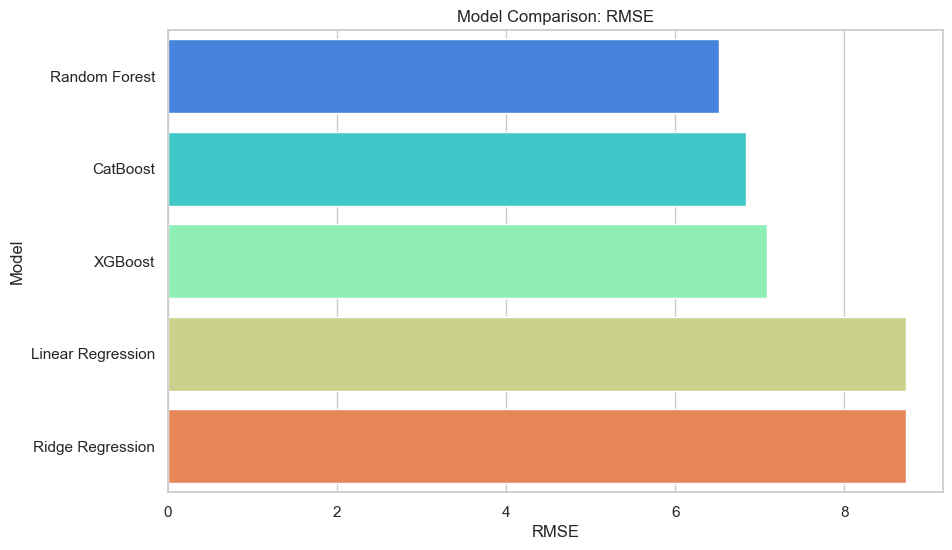

In [192]:
# RMSE
plt.figure(figsize=(10,6))
sns.barplot(x='RMSE', y='Model', data=results_df, palette='rainbow', hue='Model')
plt.title('Model Comparison: RMSE')
plt.xlabel('RMSE') # lower = better
plt.ylabel('Model')
plt.show()

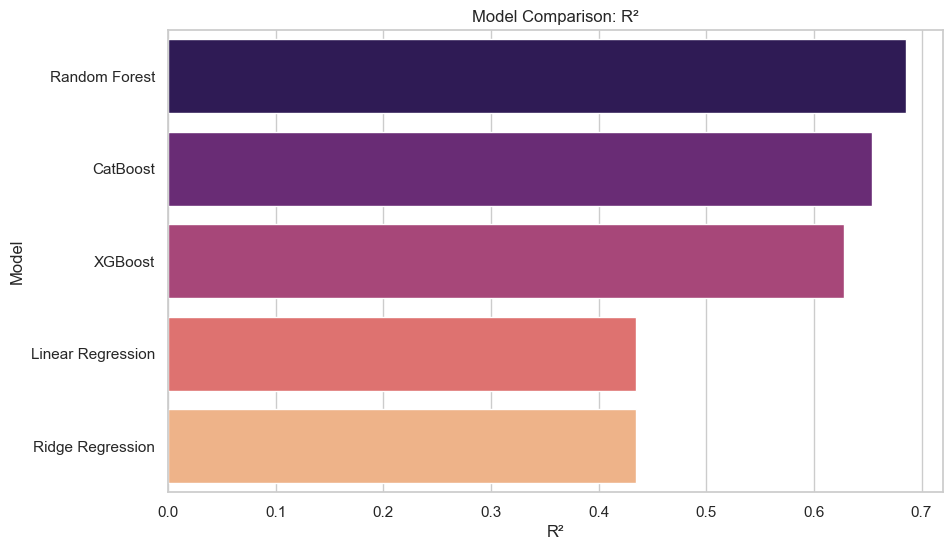

In [193]:
# R²
plt.figure(figsize=(10,6))
sns.barplot(x='R²', y='Model', data=results_df, palette='magma', hue='Model')
plt.title('Model Comparison: R²') # higher = better
plt.xlabel('R²')
plt.ylabel('Model')
plt.show()

In [212]:
# Optimizing RF regressor with RandomizedSearchCV
rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [None, 8, 12, 16],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

best_params = random_search.best_estimator_
print(best_params)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
RandomForestRegressor(max_depth=8, max_features=0.8, min_samples_leaf=5,
                      min_samples_split=10, n_estimators=200, random_state=42)


In [213]:
# Best params: (max_depth=8, max_features=0.8, min_samples_leaf=5, min_samples_split=10, random_state=42)
final_rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=0.8,
    random_state=42
)

# Train on the full training set
final_rf.fit(X_train, y_train)

# Predict and evaluate
y_pred_final = final_rf.predict(X_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)
mae_final = mean_absolute_error(y_test, y_pred_final)

print(f"Final RF - RMSE: {rmse_final:.4f}, R²: {r2_final:.4f}, MAE: {mae_final:.4f}")

Final RF - RMSE: 6.4797, R²: 0.6887, MAE: 4.0675


In [214]:
import joblib

joblib.dump(final_rf, "../RandomForestRegressor.pkl")

['../RandomForestRegressor.pkl']

In [219]:
results_df

,Model,RMSE,R²,MAE
0,Random Forest,6.511731,0.685638,4.141040
1,CatBoost,6.830341,0.654123,4.336022
2,XGBoost,7.080921,0.628280,4.455266
3,Linear Regression,8.729191,0.435082,6.273297
4,Ridge Regression,8.729758,0.435009,6.273429
